# Step 1 — Business Understanding + Problem Definition

In [ ]:
# Step 1: Business Understanding

# Objective:
# Predict Toyota Corolla car prices using Multiple Linear Regression.

# Target Variable:
# Price

# Independent Variables:
# Age, KM, FuelType, HP, Automatic,
# CC, Doors, Weight, Quarterly_Tax

# Business Goal:
# Build a regression model that helps estimate
# car prices based on vehicle characteristics.

# This is a supervised machine learning regression problem
# because the target variable (Price) is continuous.

### Real Analyst Thinking

Car pricing depends on multiple factors:

older cars → lower price

higher KM → lower price

more HP → higher price

higher weight/features → higher price

MLR helps quantify:

**how much each feature impacts price**

# Step 2 — Import Libraries + Load Dataset

In [1]:
# Step 2: Import Required Libraries

import pandas as pd
import numpy as np

# Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset

df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display first 5 rows

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
# Dataset Shape

df.shape

(1436, 11)

In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
# Summary Statistics

df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


### Real Analyst Thinking

Before modeling:

professionals always inspect:

-- data quality

-- variable types

-- missing values

-- abnormal values

-- business meaning of features

Because:

**Bad input data → bad ML models**

Very important industry mindset.

# Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
# Check Missing Values

df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(1)

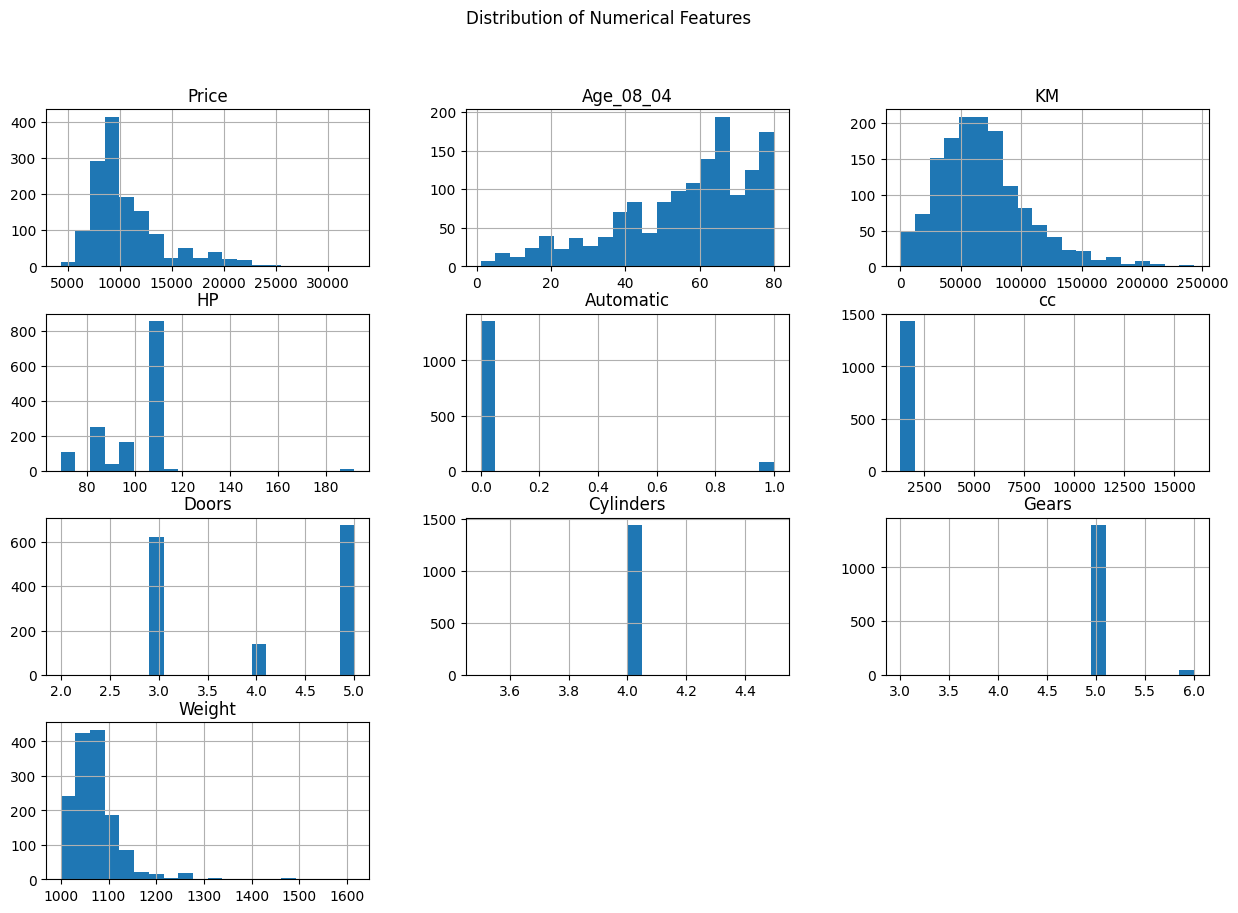

In [ ]:
# Histograms for Numerical Features

df.hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.show()

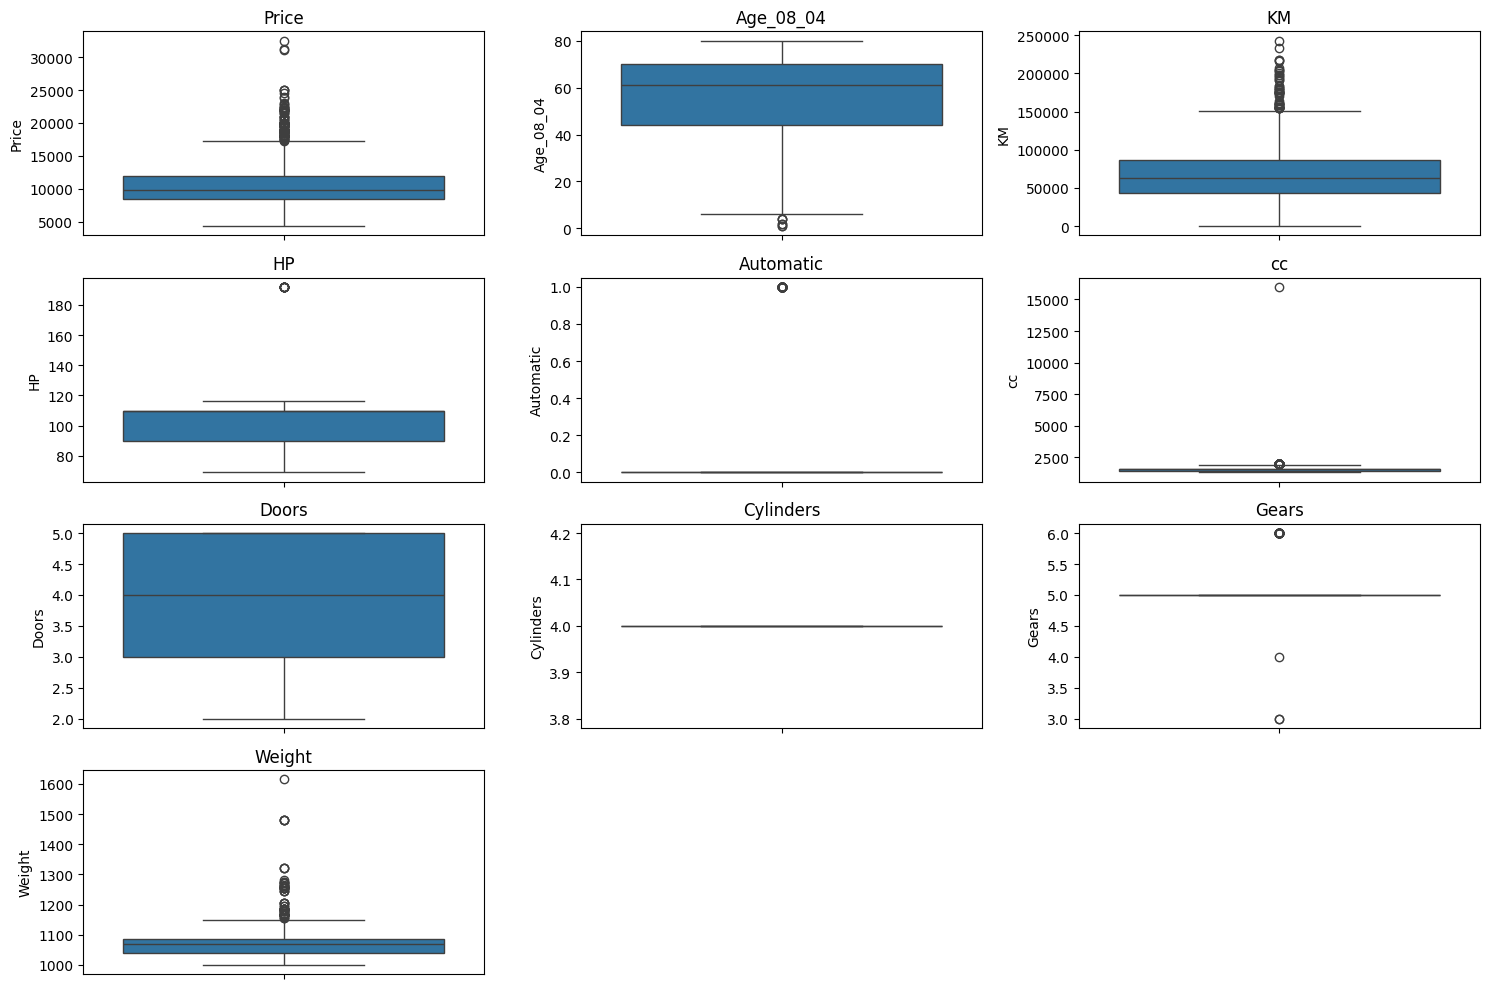

In [ ]:
# Boxplots for Outlier Detection

plt.figure(figsize=(15, 10))

for i, column in enumerate(df.select_dtypes(include=np.number).columns):

    plt.subplot(4, 3, i + 1)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()
plt.show()

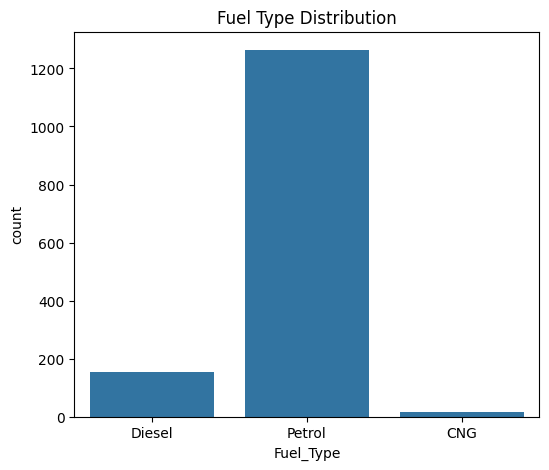

In [ ]:
# FuelType Frequency Count

plt.figure(figsize=(6, 5))

sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Distribution")
plt.show()

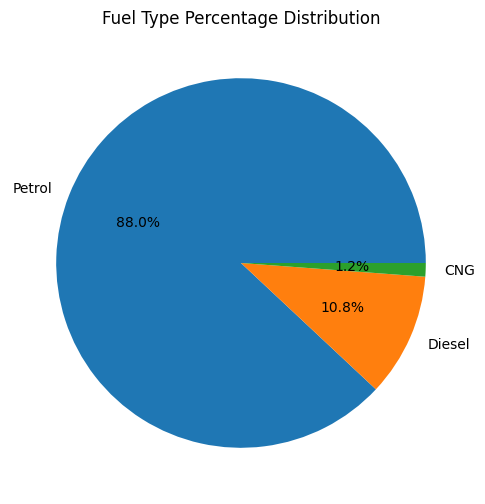

In [ ]:
# FuelType Pie Chart

df['Fuel_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6)
)

plt.title("Fuel Type Percentage Distribution")
plt.ylabel("")
plt.show()

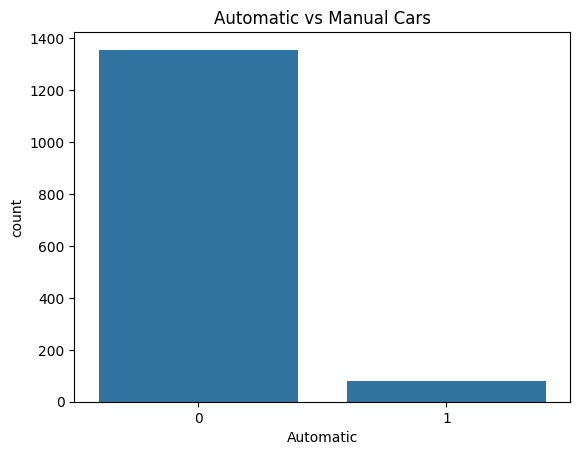

In [ ]:
# Automatic Transmission Distribution

sns.countplot(x='Automatic', data=df)

plt.title("Automatic vs Manual Cars")
plt.show()

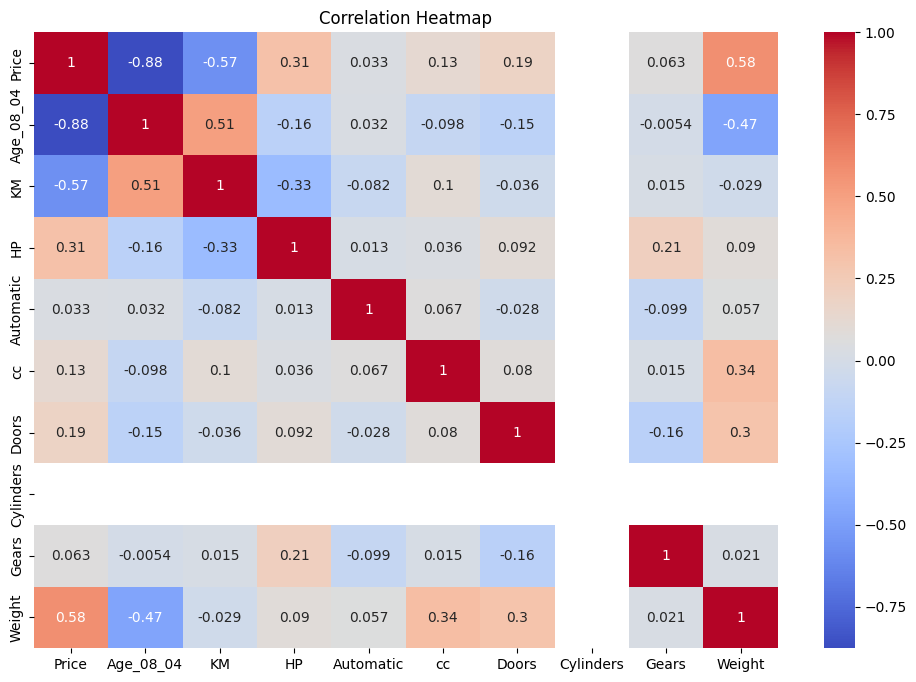

In [3]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

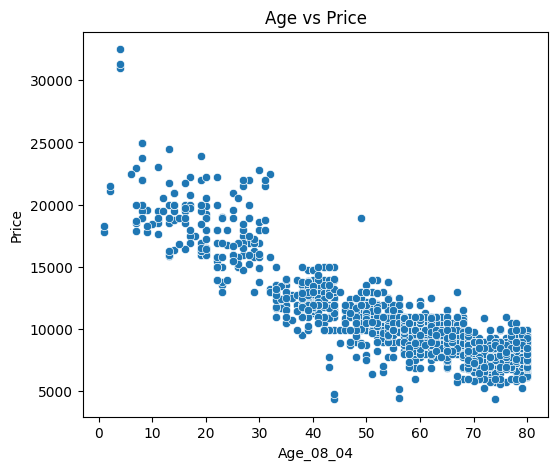

In [ ]:
# Scatter Plot: Age vs Price

plt.figure(figsize=(6, 5))

sns.scatterplot(x='Age_08_04', y='Price', data=df)

plt.title("Age vs Price")
plt.show()

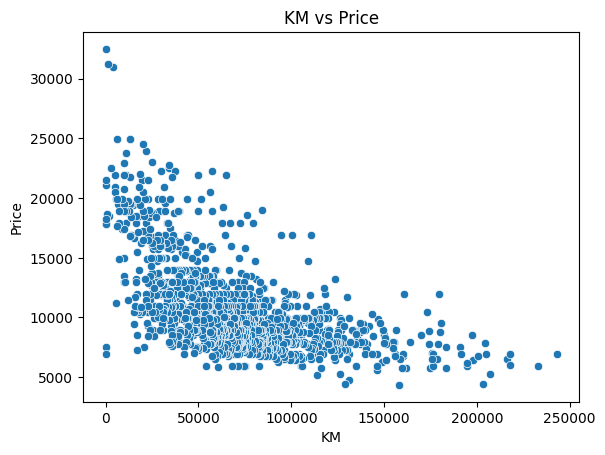

In [ ]:
# KM vs Price

sns.scatterplot(x='KM', y='Price', data=df)

plt.title("KM vs Price")
plt.show()

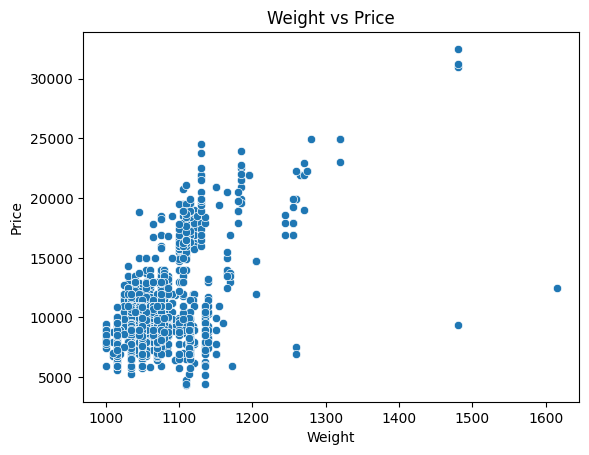

In [ ]:
# Weight vs Price

sns.scatterplot(x='Weight', y='Price', data=df)

plt.title("Weight vs Price")
plt.show()

In [ ]:
# EDA helps understand:
# - feature distributions
# - outliers
# - relationships between variables
# - business insights

### Real Analyst Thinking

EDA is where analysts discover:

**how the business actually behaves**

before modeling begins.

Strong analysts never jump directly into ML.

They first understand:

-- relationships

-- anomalies

-- patterns

-- risk factors

-- business logic


# Step 4 — Data Preprocessing

### Step 4.1: Handle Missing Values

In [ ]:
# Missing Values

df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


There is no missing values in our data, but if we had then we can perform following operations.

In [ ]:
# Fill Numerical Missing Values

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
# Fill Categorical Missing Values

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

### Step 4.2: Remove Duplicate Records

In [ ]:
df.shape

(1436, 11)

In [4]:
# Remove Duplicate Rows

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [5]:
df.shape

(1435, 11)

### Step 4.3: Encode Categorical Variables

In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=['Fuel_Type'],
    drop_first=True
)

### Why drop_first=True?

It helps avoid:

**Dummy Variable Trap**

which causes:

**multicollinearity**

Very important in regression.

### Step 4.4: Check Updated Dataset

In [7]:
# Updated Dataset

df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


### Step 4.5: Feature Selection

Now define:

X → Independent Variables

y → Target Variable

In [8]:
# Features

X = df.drop('Price', axis=1)

In [9]:
# Target Variable

y = df['Price']

### Step 4.6: Verify Shapes

In [10]:
# Shape Check

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1435, 11)
y Shape: (1435,)


### Step 4.7: Feature Scaling Discussion

For normal Linear Regression:

**scaling is NOT mandatory**

But for:

-- Ridge Regression
-- Lasso Regression

scaling is highly recommended.

We will do scaling later before Ridge/Lasso.

### Real Analyst Thinking

Preprocessing is often:

**more important than modeling itself**

because:

-- clean data improves predictions

-- correct encoding improves learning

-- bad preprocessing destroys model quality

Strong analysts spend major effort here.

This is real-world ML workflow.

# Step 5 — Train-Test Split

### Why Do We Split the Data?

If we train and test on the same data:

-- the model may memorize patterns

-- evaluation becomes unrealistic

-- overfitting risk increases

This gives:

**misleadingly high accuracy**

Very dangerous in real-world ML.

**Industry Standard Approach**

Typically:

--> 80% → Training Data

--> 20% → Testing Data

In [11]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1148, 11)
X_test Shape : (287, 11)
y_train Shape: (1148,)
y_test Shape : (287,)


### Important Parameters
#### **test_size=0.20**

Means:

**20% data used for testing**

Remaining:

**80% used for training**

#### **random_state=42**

This ensures:

**reproducibility**

Meaning:

every time the code runs,

the same train-test split is generated.

Very important for consistency.

## Step 5.2: Why Training Data Matters

The model learns:

-- patterns

-- relationships

-- coefficients

from:

**training data only**

This is where actual learning happens.

## Step 5.3: Why Testing Data Matters

Testing data is:

**unseen data**

used to evaluate:

-- prediction accuracy

-- generalization ability

-- real-world performance

## Real Analyst Thinking

A good ML model should not only:

**perform well on training data**

It should also:

**perform well on unseen data**

This is called:

**Generalization**

Very important ML concept.

## Step 5.4: Understanding Overfitting

If a model performs:

--> extremely well on training data

but:

--> poorly on testing data

this is called:

**Overfitting**

Meaning:

the model memorized training patterns instead of learning general relationships.

## Step 5.5: Real Business Importance

Businesses care about:

**future predictions**

not memorization.

A dealership wants the model to predict:

-- future car prices

-- unseen vehicles

-- new customer inventory

So testing on unseen data is critical.

This is real-world ML validation.

# Step 6 — Build Multiple Linear Regression Models

### Step 6.1 — Model 1 (Using All Features)

In [12]:
# Step 6: Model 1 - Multiple Linear Regression

from sklearn.linear_model import LinearRegression

# Create Model

model_1 = LinearRegression()

# Train Model

model_1.fit(X_train, y_train)

print("Model 1 Trained Successfully")

Model 1 Trained Successfully


In [13]:
# Predictions on Test Data

y_pred_1 = model_1.predict(X_test)

In [14]:
# Model Coefficients

coefficients_1 = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_1.coef_
})

coefficients_1

,Feature,Coefficient
0,Age_08_04,-1.212292e+02
1,KM,-1.599715e-02
2,HP,1.607544e+01
3,Automatic,2.688222e+02
4,cc,-4.710949e-02
5,Doors,-8.809716e+01
6,Cylinders,1.136868e-13
7,Gears,4.550119e+02
8,Weight,2.636120e+01
9,Fuel_Type_Diesel,-3.896838e+02


### Why Coefficients Matter

Coefficients show:

**how much Price changes**

when one feature increases by 1 unit,

while other variables remain constant.

Very important business interpretation.

### Step 6.2 — Model 2 (Selected Features)

Now we build a simpler model using important features only.

In [15]:
# Selected Important Features

selected_features = [
    'Age_08_04',
    'KM',
    'HP',
    'Weight'
]

X_selected = df[selected_features]

In [16]:
# Train-Test Split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
# Model 2

model_2 = LinearRegression()

model_2.fit(X_train2, y_train2)

y_pred_2 = model_2.predict(X_test2)

print("Model 2 Trained Successfully")

Model 2 Trained Successfully


#### Why Build Smaller Models?

Smaller models may:

-- reduce complexity

-- improve interpretability

-- reduce overfitting

-- improve business usability

Very important concept.

### Step 6.3 — Model 3 (Highly Correlated Features)

Now build another model using:

**strongest predictors**

identified from correlation heatmap.

In [18]:
# Model 3 Features

features_model3 = [
    'Age_08_04',
    'Weight',
    'HP'
]

X_model3 = df[features_model3]

In [19]:
# Train-Test Split

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_model3,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
# Model 3

model_3 = LinearRegression()

model_3.fit(X_train3, y_train3)

y_pred_3 = model_3.predict(X_test3)

print("Model 3 Trained Successfully")

Model 3 Trained Successfully


#### Why Compare Multiple Models?

Professionals compare models to find:

-- best performance

-- simplest explainable model

-- best business tradeoff

-- lowest overfitting risk

This is real-world ML workflow.

### Real Analyst Thinking

In industry:

the best model is NOT always:

**the most complex model**

Sometimes simpler models are preferred because:

-- easier to explain

-- faster to deploy

-- lower maintenance

-- more interpretable

This is extremely important in business analytics.

# Step 7 — Evaluate Model Performance

### Evaluation Metrics We Will Use

We will calculate:

| Metric   | Purpose                  |
| -------- | ------------------------ |
| MAE      | Average absolute error   |
| MSE      | Squared prediction error |
| RMSE     | Error in original units  |
| R² Score | Goodness of fit          |

These are industry-standard regression metrics.

### Step 7.1: Import Evaluation Metrics

In [21]:
# Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

### Step 7.2 — Evaluate Model 1

In [22]:
# Model 1 Evaluation

mae_1 = round(mean_absolute_error(y_test, y_pred_1), 2)

mse_1 = round(mean_squared_error(y_test, y_pred_1), 2)

rmse_1 = round(np.sqrt(mse_1), 2)

r2_1 = round(r2_score(y_test, y_pred_1), 4)

print("Model 1 Performance")
print("---------------------")

print("MAE :", mae_1)
print("MSE :", mse_1)
print("RMSE:", rmse_1)
print("R² Score:", r2_1)

Model 1 Performance
---------------------
MAE : 986.5
MSE : 2155628.36
RMSE: 1468.21
R² Score: 0.8203


### Step 7.3 — Evaluate Model 2

In [23]:
# Model 2 Evaluation

mae_2 = round(mean_absolute_error(y_test2, y_pred_2), 2)

mse_2 = round(mean_squared_error(y_test2, y_pred_2), 2)

rmse_2 = round(np.sqrt(mse_2), 2)

r2_2 = round(r2_score(y_test2, y_pred_2), 4)

print("Model 2 Performance")
print("---------------------")

print("MAE :", mae_2)
print("MSE :", mse_2)
print("RMSE:", rmse_2)
print("R² Score:", r2_2)

Model 2 Performance
---------------------
MAE : 987.23
MSE : 1934478.82
RMSE: 1390.86
R² Score: 0.8388


### Step 7.4 — Evaluate Model 3

In [24]:
# Model 3 Evaluation

mae_3 = round(mean_absolute_error(y_test3, y_pred_3), 2)

mse_3 = round(mean_squared_error(y_test3, y_pred_3), 2)

rmse_3 = round(np.sqrt(mse_3), 2)

r2_3 = round(r2_score(y_test3, y_pred_3), 4)

print("Model 3 Performance")
print("---------------------")

print("MAE :", mae_3)
print("MSE :", mse_3)
print("RMSE:", rmse_3)
print("R² Score:", r2_3)

Model 3 Performance
---------------------
MAE : 1097.34
MSE : 2205322.17
RMSE: 1485.03
R² Score: 0.8162


### Step 7.5 — Create Comparison Table

In [25]:
# Comparison Table

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],

    'MAE': [mae_1, mae_2, mae_3],

    'MSE': [mse_1, mse_2, mse_3],

    'RMSE': [rmse_1, rmse_2, rmse_3],

    'R² Score': [r2_1, r2_2, r2_3]
})

results

,Model,MAE,MSE,RMSE,R² Score
0,Model 1,986.50,2155628.36,1468.21,0.8203
1,Model 2,987.23,1934478.82,1390.86,0.8388
2,Model 3,1097.34,2205322.17,1485.03,0.8162


### Step 7.6: Understanding the Metrics

#### 1. MAE (Mean Absolute Error)

Formula:

MAE = (1/n) * ∑|yi - yi^|

Measures:

**average prediction error**

Smaller MAE →

--> better predictions


#### 2. MSE (Mean Squared Error)

Formula:

MSE = (1/n) * ∑square(yi - yi^)

Penalizes:

**larger errors more heavily**

Useful for detecting large prediction mistakes.


#### 3. RMSE (Root Mean Squared Error)

Formula:

RMSE = sqrt(MSE)

Very important metric.

Why?

Because RMSE is in:

**same units as target variable (Price)**

Easy for business interpretation.


#### 4. R² Score

Formula:

R2 = 1 - ​SSres / SStot​​

Measures:

**how much variance the model explains**

##### R² Interpretation

| R² Value | Meaning             |
| -------- | ------------------- |
| 1.0      | Perfect prediction  |
| 0.0      | No predictive power |
| Higher   | Better model        |



### Step 7.7: Model Selection Logic
Best Model Usually Has:

-- highest R²

-- lowest MAE

-- lowest RMSE

But also consider:

--> interpretability

--> simplicity

--> business usability

Very important industry thinking.

### Real Analyst Thinking

In real business environments:

companies care less about formulas and more about:

**prediction reliability**

For example:

a dealership wants:

-- accurate resale pricing

-- fewer pricing mistakes

-- consistent predictions

Regression evaluation metrics measure exactly that.

This is real-world ML validation.

# Step 8 — Apply Ridge & Lasso Regression

### Regularization Techniques

using:

--> Ridge Regression

--> Lasso Regression

These are extremely important in real-world Machine Learning because they help:

-- reduce overfitting

-- improve generalization

-- handle multicollinearity

-- stabilize coefficients

### Step 8.1: Why Regularization is Needed?

In Multiple Linear Regression:

if features are highly correlated,

the model may suffer from:

**Multicollinearity**

This can cause:

-- unstable coefficients

-- overfitting

-- poor generalization

-- unreliable predictions

Regularization helps solve this.

### Step 8.2: Difference Between Ridge and Lasso

| Technique | Penalty Type | Main Benefit                  |
| --------- | ------------ | ----------------------------- |
| Ridge     | L2 Penalty   | Reduces coefficient magnitude |
| Lasso     | L1 Penalty   | Performs feature selection    |


### Step 8.3: Feature Scaling Before Regularization
Very important.

Ridge and Lasso are:

**scale-sensitive algorithms**

So we must standardize features first.

In [26]:
# Feature Scaling
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [27]:
# Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Why Standardization Matters

Standardization transforms features to:

**μ = 0, σ = 1**

This ensures:

-- fair coefficient penalization

-- stable optimization

-- better regularization performance

### Step 8.4 — Ridge Regression

In [28]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

# Predictions

ridge_pred = ridge_model.predict(X_test_scaled)

print("Ridge Regression Model Trained Successfully")

Ridge Regression Model Trained Successfully


#### What is alpha?

alpha controls:

**regularization strength**

**Higher alpha →**

-- stronger penalty

-- smaller coefficients

-- lower overfitting

But:

--> **may underfit if too large**

Very important.

### Step 8.5 — Evaluate Ridge Regression

In [30]:
# Ridge Evaluation

ridge_mae = round(mean_absolute_error(y_test, ridge_pred), 2)

ridge_mse = round(mean_squared_error(y_test, ridge_pred), 2)

ridge_rmse = round(np.sqrt(ridge_mse), 2)

ridge_r2 = round(r2_score(y_test, ridge_pred), 4)

print("Ridge Regression Performance")
print("-----------------------------")

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression Performance
-----------------------------
MAE : 986.42
MSE : 2153029.96
RMSE: 1467.32
R² Score: 0.8205


### Step 8.6 — Lasso Regression

In [31]:
# Lasso Regression

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_scaled, y_train)

# Predictions

lasso_pred = lasso_model.predict(X_test_scaled)

print("Lasso Regression Model Trained Successfully")

Lasso Regression Model Trained Successfully


#### Why Lasso is Special

Lasso can shrink some coefficients to:

**exactly zero**

Meaning:

**automatic feature selection**

### Step 8.7 — Evaluate Lasso Regression

In [33]:
# Lasso Evaluation

lasso_mae = round(mean_absolute_error(y_test, lasso_pred), 2)

lasso_mse = round(mean_squared_error(y_test, lasso_pred), 2)

lasso_rmse = round(np.sqrt(lasso_mse), 2)

lasso_r2 = round(r2_score(y_test, lasso_pred), 4)

print("Lasso Regression Performance")
print("-----------------------------")

print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R² Score:", lasso_r2)

Lasso Regression Performance
-----------------------------
MAE : 986.17
MSE : 2151496.85
RMSE: 1466.8
R² Score: 0.8207


### Step 8.8 — Compare Ridge & Lasso

In [34]:
# Ridge vs Lasso Comparison

regularization_results = pd.DataFrame({

    'Model': ['Ridge Regression', 'Lasso Regression'],

    'MAE': [ridge_mae, lasso_mae],

    'MSE': [ridge_mse, lasso_mse],

    'RMSE': [ridge_rmse, lasso_rmse],

    'R² Score': [ridge_r2, lasso_r2]
})

regularization_results

,Model,MAE,MSE,RMSE,R² Score
0,Ridge Regression,986.42,2153029.96,1467.32,0.8205
1,Lasso Regression,986.17,2151496.85,1466.80,0.8207


### Step 8.9 — Ridge vs Lasso Interpretation

**Ridge Regression**

-- reduces coefficient magnitude

-- handles multicollinearity well

-- keeps all features

**Lasso Regression**

-- performs feature selection

-- removes less important features

-- creates simpler models

Very important industry difference.

### Step 8.10: Coefficient Comparison

In [35]:
# Lasso Coefficients

lasso_coefficients = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': lasso_model.coef_
})

lasso_coefficients

,Feature,Coefficient
0,Age_08_04,-2265.964667
1,KM,-604.937502
2,HP,242.591272
3,Automatic,59.203768
4,cc,-20.717481
5,Doors,-82.022751
6,Cylinders,0.000000
7,Gears,80.155159
8,Weight,1329.207970
9,Fuel_Type_Diesel,-120.150110


In [36]:
# Ridge Coefficients

ridge_coefficients = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': ridge_model.coef_
})

ridge_coefficients

,Feature,Coefficient
0,Age_08_04,-2263.971502
1,KM,-606.016898
2,HP,242.895665
3,Automatic,60.040885
4,cc,-21.802890
5,Doors,-82.955069
6,Cylinders,0.000000
7,Gears,80.889118
8,Weight,1330.726151
9,Fuel_Type_Diesel,-121.764008


### Real Analyst Thinking

In real-world business systems:

models must:

--> generalize well

--> avoid overfitting

--> remain stable

--> work on unseen data

Regularization helps build:

**production-ready ML models**

This is exactly what companies use.

# Professional Conclusion

In this project, Multiple Linear Regression analysis was performed to predict Toyota Corolla prices using multiple vehicle-related attributes such as age, kilometers driven, fuel type, horsepower, weight, and engine specifications.

The project began with Exploratory Data Analysis (EDA), where feature distributions, correlations, categorical variables, and outliers were analyzed to understand the dataset structure and business relationships.

Several important business insights were identified:

--> older vehicles generally had lower resale prices

--> higher kilometers reduced car value

--> features such as horsepower and weight positively influenced pricing

Data preprocessing was then performed, including:

-- missing value handling

-- duplicate removal

-- one-hot encoding of categorical variables

-- feature preparation for regression modeling

Three different Multiple Linear Regression models were built and compared using:

--- MAE

--- MSE

--- RMSE

--- R² Score

This helped evaluate model performance, prediction accuracy, and feature importance.

The project also introduced:

**Ridge Regression**

and

**Lasso Regression**

to address multicollinearity and reduce overfitting.

Ridge Regression improved coefficient stability, while Lasso Regression performed feature selection by shrinking less important coefficients toward zero.

Overall, the project demonstrated how regression modeling can help businesses estimate product pricing using historical data and feature relationships.

This type of predictive modeling is highly valuable in real-world applications such as:

-- used car pricing systems

-- dealership inventory valuation

-- resale price estimation

-- automotive market analytics

-- pricing recommendation systems

The project strengthened understanding of:

--> Multiple Linear Regression

--> Feature Engineering

--> Model Evaluation

--> Regularization Techniques

--> Business Interpretation of ML Models

--> Production-Oriented Predictive Analytics

This is exactly how machine learning is applied in practical business environments.

# Interview Questions

### What is Normalization & Standardization and how is it helpful?

**Normalization**

Normalization scales data into a fixed range, usually:

**0 to 1**

Formula:

Xnorm	= X - Xmin / ​Xmax - Xmin

Used when:

--> feature ranges vary significantly

--> distance-based algorithms are used

**Standardization**

Standardization transforms data into:

**μ=0, σ=1**

Formula:

Xstd ​= X − μ / σ​

Used when:

--> data follows normal distribution

--> regression and regularization models are used

**Why Helpful?**

They help:

-- improve model performance

-- speed up optimization

-- ensure fair feature contribution

-- improve regularization behavior

Very important for Ridge & Lasso Regression.

### What techniques can be used to address multicollinearity in Multiple Linear Regression?

Several techniques can reduce multicollinearity:

#### **1. Remove Highly Correlated Features**

Using correlation analysis or VIF (Variance Inflation Factor).

#### **2. Feature Selection**

Keep only important independent variables.

#### **3. Ridge Regression**

Reduces coefficient instability using L2 regularization.

#### **4. Lasso Regression**

Performs feature selection using L1 regularization.

#### **5. Principal Component Analysis (PCA)**

Transforms correlated variables into independent components.

**Why Multicollinearity is Dangerous?**

Because it can cause:

--> unstable coefficients

--> poor interpretability

--> unreliable predictions